# Procesamiento del lenguaje natural(NLP)

## Importación de librerías, paquetes y definición de constantes

In [715]:
import pandas as pd
import matplotlib.pyplot as plt
# Limpieza de texto y vectorización
import regex as re
from nltk import download
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from wordcloud import WordCloud
from sklearn.feature_extraction.text import TfidfVectorizer
# Modelado
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.svm import SVC
# Optimización
from sklearn.model_selection import GridSearchCV, cross_val_score
from sklearn.model_selection import RandomizedSearchCV
# Guardar modelos
import json
import pickle
# Warnings
import warnings


In [ ]:
warnings.filterwarnings("ignore")

## Recopilación de datos

In [665]:
df = pd.read_csv("../data/raw/url_spam.csv")
df.head()

,url,is_spam
0,https://briefingday.us8.list-manage.com/unsubs...,True
1,https://www.hvper.com/,True
2,https://briefingday.com/m/v4n3i4f3,True
3,https://briefingday.com/n/20200618/m#commentform,False
4,https://briefingday.com/fan,True


## Análisis descriptivo 

In [666]:
df

,url,is_spam
0,https://briefingday.us8.list-manage.com/unsubs...,True
1,https://www.hvper.com/,True
2,https://briefingday.com/m/v4n3i4f3,True
3,https://briefingday.com/n/20200618/m#commentform,False
4,https://briefingday.com/fan,True
...,...,...
2994,https://www.smartcitiesworld.net/news/news/dee...,False
2995,https://www.youtube.com/watch,True
2996,https://techcrunch.com/2019/07/04/an-optimisti...,False
2997,https://www.technologyreview.com/2019/12/20/13...,False


In [667]:
df.shape

(2999, 2)

In [668]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2999 entries, 0 to 2998
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   url      2999 non-null   object
 1   is_spam  2999 non-null   bool  
dtypes: bool(1), object(1)
memory usage: 26.5+ KB


In [669]:
df.nunique()

url        2369
is_spam       2
dtype: int64

## Limpieza de datos

### Eliminar duplicados:

In [670]:
df.duplicated().sum()

630

### No hay duplicados pero nos aseguramos de borrarlos

In [671]:
if df.duplicated().sum():
    df = df.drop_duplicates(keep='first')
print(df.shape)
df.head()

(2369, 2)


,url,is_spam
0,https://briefingday.us8.list-manage.com/unsubs...,True
1,https://www.hvper.com/,True
2,https://briefingday.com/m/v4n3i4f3,True
3,https://briefingday.com/n/20200618/m#commentform,False
4,https://briefingday.com/fan,True


In [672]:
df.duplicated().sum()

0

### Valores nulos o faltantes:

In [673]:
df.isnull().sum().sort_values(ascending=False) / len(df)

url        0.0
is_spam    0.0
dtype: float64

#### No hay valores nulos

### Transformamos la variable "is_spam" a valores enteros entre 0 y 1

In [674]:
df["is_spam"] = df["is_spam"].apply(lambda x: 1 if x == True else 0).astype(int)
df

C:\Users\Simón\AppData\Local\Temp\ipykernel_15260\1321679270.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["is_spam"] = df["is_spam"].apply(lambda x: 1 if x == True else 0).astype(int)


,url,is_spam
0,https://briefingday.us8.list-manage.com/unsubs...,1
1,https://www.hvper.com/,1
2,https://briefingday.com/m/v4n3i4f3,1
3,https://briefingday.com/n/20200618/m#commentform,0
4,https://briefingday.com/fan,1
...,...,...
2993,https://www.theverge.com/2020/6/29/21306889/di...,0
2994,https://www.smartcitiesworld.net/news/news/dee...,0
2996,https://techcrunch.com/2019/07/04/an-optimisti...,0
2997,https://www.technologyreview.com/2019/12/20/13...,0


## Procesamiento del texto

### Para poder entrenar el modelo es necesario aplicar antes un proceso de transformación al texto. Comenzamos transformando el texto a minúsculas y eliminando signos de puntuación y caracteres especiales:

### Cleaning

In [675]:
def preprocess_text(text):
    text = text.lower()
    # Reemplaza https://www o https// o http por un espacio en blanco
    text = re.sub(r'^https?://www|https?://' , '', text)
    # Reemplaza los separadores por un espacio en blanco
    text = re.sub(r'[-./]', ' ', text)
    # Reemplaza los dominios .com .edu y .org por un espacio en blanco
    text = re.sub(r'\bcom\b|\bedu\b|\borg\b' , '', text)
    # Reemplaza aquello que no es una letra (a-z) o un número  por un espacio en blanco
    text = re.sub(r'[^a-z-0-9]', " ", text)
    # Reemplaza múltiples espacios en blanco en uno solo
    text = re.sub(r'\s+', " ", text)
    return text.split()


In [676]:
df["url"] = df["url"].apply(preprocess_text)
df

C:\Users\Simón\AppData\Local\Temp\ipykernel_15260\681106133.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["url"] = df["url"].apply(preprocess_text)


,url,is_spam
0,"[briefingday, us8, list, manage, unsubscribe]",1
1,[hvper],1
2,"[briefingday, m, v4n3i4f3]",1
3,"[briefingday, n, 20200618, m, commentform]",0
4,"[briefingday, fan]",1
...,...,...
2993,"[theverge, 2020, 6, 29, 21306889, disney, deep...",0
2994,"[smartcitiesworld, net, news, news, deepfake, ...",0
2996,"[techcrunch, 2019, 07, 04, an, optimistic, vie...",0
2997,"[technologyreview, 2019, 12, 20, 131462, this,...",0


### Lematización

In [677]:
# Instancia lematizador
download("wordnet")
lemmatizer = WordNetLemmatizer()

download("stopwords")
stop_words = stopwords.words("english")

def lemmatize_text(words, lemmatizer=lemmatizer):
    # lematiza
    tokens = [lemmatizer.lemmatize(word) for word in words]
    # saca stop words
    tokens = [word for word in tokens if word not in stop_words]
    # se queda con las de largo mayor a
    tokens = [word for word in tokens if len(word) > 3]
    return tokens

[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\Simón\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Simón\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [678]:
df["url"] = df["url"].apply(lemmatize_text)
df

C:\Users\Simón\AppData\Local\Temp\ipykernel_15260\3550684308.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["url"] = df["url"].apply(lemmatize_text)


,url,is_spam
0,"[briefingday, list, manage, unsubscribe]",1
1,[hvper],1
2,"[briefingday, v4n3i4f3]",1
3,"[briefingday, 20200618, commentform]",0
4,[briefingday],1
...,...,...
2993,"[theverge, 2020, 21306889, disney, deepfake, f...",0
2994,"[smartcitiesworld, news, news, deepfake, techn...",0
2996,"[techcrunch, 2019, optimistic, view, deepfakes]",0
2997,"[technologyreview, 2019, 131462, startup, clai...",0


### Nube de palabras

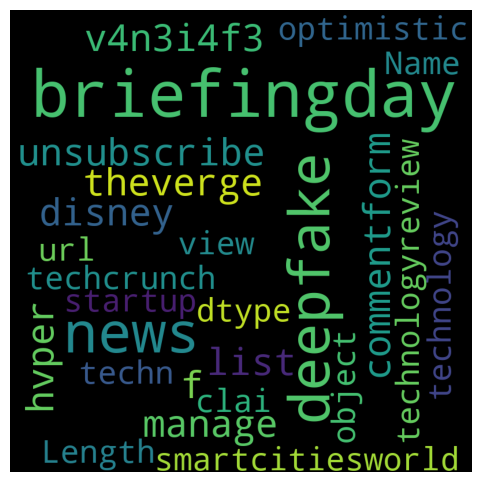

In [679]:
wordcloud = WordCloud(width=800,
                      height=800,
                      background_color="black",
                      max_words=1000,
                      min_font_size=20,
                      random_state=24).generate(str(df["url"]))

fig = plt.figure(figsize=(6, 6), facecolor=None)
plt.imshow(wordcloud)
plt.axis("off")
plt.show()

### Observamos que las palabras más destacadas son "briefingday", "deepfake", "news", "commentform", etc

## Split de datos


#### `TfidfVectorizer` toma una ponderación de los pesos de las excepciones, es decir, le da importancia a palabras únicas

In [680]:
tokens_list = df["url"]
tokens_list = [" ".join(tokens) for tokens in tokens_list]

vectorizer = TfidfVectorizer(max_features=5000,
                             max_df=0.8,
                             min_df=5)

X = vectorizer.fit_transform(tokens_list).toarray()
y = df["is_spam"]

X[:5]

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]])

In [681]:
X_train, X_test, y_train, y_test = train_test_split(X,
                                                    y,
                                                    test_size=0.2,
                                                    random_state=24)
X_train

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]])

In [683]:
X_test

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]])

## Generación del modelo y ajuste

### Trabajamos con un modelo de SVM 

In [684]:
model_svc = SVC(kernel="linear",
                random_state=24)

### Entrenamiento

In [685]:
model_svc.fit(X_train, y_train)

,C,1.0
,kernel,'linear'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


### Predicción

In [686]:
y_pred = model_svc.predict(X_test)
y_pred

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0,
       0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,

### Métricas

In [687]:
accuracy_score(y_test, y_pred)

0.959915611814346

In [688]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.96      0.99      0.98       431
           1       0.90      0.63      0.74        43

    accuracy                           0.96       474
   macro avg       0.93      0.81      0.86       474
weighted avg       0.96      0.96      0.96       474



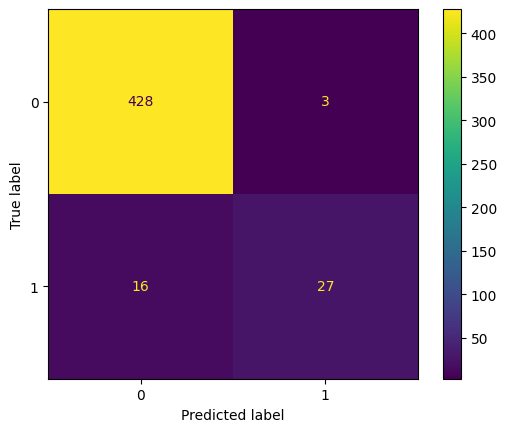

In [689]:
cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm).plot()
plt.show()

### El modelo detecta con alta precisión los casos de "no spam" pero falla al detectar las etiquetas de "spam". Intentamos mejorarlo con la optimización de hiperparámetros

## Optimización del modelo con `GridSearchCV`

### Parámetros para la cuadrícula

In [711]:
param_grid = param_grid = {'C': [0.1, 1, 10],
                           'kernel': ['linear', 'rbf'],
                           'gamma': ['scale', 'auto', 0.1, 1]
                           }
grid_search = GridSearchCV(estimator=model_svc,
                           param_grid=param_grid,
                           cv=5,
                           refit='accuracy'
                           )


In [712]:
grid_search.fit(X_train, y_train)

,estimator,SVC(kernel='l...ndom_state=24)
,param_grid,"{'C': [0.1, 1, ...], 'gamma': ['scale', 'auto', ...], 'kernel': ['linear', 'rbf']}"
,scoring,None
,n_jobs,None
,refit,'accuracy'
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,C,10


In [710]:
grid_search.best_params_

{'C': 10, 'gamma': 0.1, 'kernel': 'rbf'}

In [713]:
grid_svc = grid_search.best_estimator_
y_pred_grid = grid_svc.predict(X_test)

In [714]:
accuracy_score(y_test, y_pred_grid)

0.959915611814346

In [705]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.96      0.99      0.98       431
           1       0.90      0.63      0.74        43

    accuracy                           0.96       474
   macro avg       0.93      0.81      0.86       474
weighted avg       0.96      0.96      0.96       474



## Conclusiones

- ### El modelo generaliza muy bien para los casos de "no spam" pero falla al detectar los casos de "spam"
- ### La optimización de hiperparámetros no mejora el resultado
- ### Este resultado se puede deber al desbalance que existe en el conjunto de datos, hay muchos más casos de no spam que de spam
- ### Aceptamos el modelo como suficiente para trabajar


## Probamos el modelo

In [719]:
new_message = """https://www.free-suscribe.org/"""
# Aplicar preprocesamiento y lematización
processed_message = preprocess_text(new_message)
lemmatized_message = lemmatize_text(processed_message, lemmatizer)
# Unir tokens en una sola cadena
lemmatized_message = " ".join(lemmatized_message)
# Vectorizamos
vectorized_message = vectorizer.transform([lemmatized_message]).toarray()
# Realizar predicción
prediction = model_svc.predict(vectorized_message)
# Mostrar resultado
f'Predicción: {"Spam" if prediction[0] == 1 else "No Spam"}'

'Predicción: No Spam'

## Guardado de modelos

In [716]:
model = model_svc
with open('C:/Users/Simón/sayons-intro-ml-new/models/modelo-svc-npl.pkl', 'wb') as file:
    pickle.dump(model, file)